In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read the csv file
df_tissue_specific_deepmix = pd.read_csv('./_doc/result_tissue_specific_deepmix.csv', index_col=0, header=0)
df_tissue_specific_cnnc = pd.read_csv('./_doc/result_tissue_specific_cnnc.csv', index_col=0, header=0)
df_tissue_specific_dgrns = pd.read_csv('./_doc/result_tissue_specific_dgrns.csv', index_col=0, header=0)
df_tissue_specific_stgrns = pd.read_csv('./_doc/result_tissue_specific_stgrns.csv', index_col=0, header=0)
df_tissue_specific_genelink = pd.read_csv('./_doc/result_tissue_specific_genelink.csv', index_col=0, header=0)
df_tissue_specific_deeptfni = pd.read_csv('./_doc/result_tissue_specific_deeptfni.csv', index_col=0, header=0)
df_tissue_specific_deepsem = pd.read_csv('./_doc/result_tissue_specific_deepsem.csv', index_col=0, header=0)


# group by the same dataset
df_tissue_specific_deepmix.insert(0, 'dataset', df_tissue_specific_deepmix.index)
df_tissue_specific_deepmix = df_tissue_specific_deepmix.drop_duplicates(subset=['dataset', 'seed', 'cell', 'size'], keep='first')
df_tissue_specific_deepmix = df_tissue_specific_deepmix[(df_tissue_specific_deepmix['cell'] == 5000) & (df_tissue_specific_deepmix['size'] == 1.0)]
df_tissue_specific_deepmix = df_tissue_specific_deepmix[['auroc', 'aupr', 'aupr_norm', 'ep', 'epr']]
df_tissue_specific_cnnc.insert(0, 'dataset', df_tissue_specific_cnnc.index)
df_tissue_specific_cnnc = df_tissue_specific_cnnc.drop_duplicates(subset=['dataset', 'seed', 'cell', 'size'], keep='first')
df_tissue_specific_cnnc = df_tissue_specific_cnnc[(df_tissue_specific_cnnc['cell'] == 5000) & (df_tissue_specific_cnnc['size'] == 1.0)]
df_tissue_specific_cnnc = df_tissue_specific_cnnc[['auroc', 'aupr', 'aupr_norm', 'ep', 'epr']]
df_tissue_specific_dgrns.insert(0, 'dataset', df_tissue_specific_dgrns.index)
df_tissue_specific_dgrns = df_tissue_specific_dgrns.drop_duplicates(subset=['dataset', 'seed', 'cell', 'size'], keep='first')
df_tissue_specific_dgrns = df_tissue_specific_dgrns[(df_tissue_specific_dgrns['cell'] == 5000) & (df_tissue_specific_dgrns['size'] == 1.0)]
df_tissue_specific_dgrns = df_tissue_specific_dgrns[['auroc', 'aupr', 'aupr_norm', 'ep', 'epr']]
df_tissue_specific_stgrns.insert(0, 'dataset', df_tissue_specific_stgrns.index)
df_tissue_specific_stgrns = df_tissue_specific_stgrns.drop_duplicates(subset=['dataset', 'seed', 'cell', 'size'], keep='first')
df_tissue_specific_stgrns = df_tissue_specific_stgrns[(df_tissue_specific_stgrns['cell'] == 5000) & (df_tissue_specific_stgrns['size'] == 1.0)]
df_tissue_specific_stgrns = df_tissue_specific_stgrns[['auroc', 'aupr', 'aupr_norm', 'ep', 'epr']]
df_tissue_specific_genelink.insert(0, 'dataset', df_tissue_specific_genelink.index)
df_tissue_specific_genelink = df_tissue_specific_genelink.drop_duplicates(subset=['dataset', 'seed', 'cell', 'size'], keep='first')
df_tissue_specific_genelink = df_tissue_specific_genelink[(df_tissue_specific_genelink['cell'] == 5000) & (df_tissue_specific_genelink['size'] == 1.0)]
df_tissue_specific_genelink = df_tissue_specific_genelink[['auroc', 'aupr', 'aupr_norm', 'ep', 'epr']]
df_tissue_specific_deeptfni.insert(0, 'dataset', df_tissue_specific_deeptfni.index)
df_tissue_specific_deeptfni = df_tissue_specific_deeptfni.drop_duplicates(subset=['dataset', 'seed', 'cell', 'size'], keep='first')
df_tissue_specific_deeptfni = df_tissue_specific_deeptfni[(df_tissue_specific_deeptfni['cell'] == 5000) & (df_tissue_specific_deeptfni['size'] == 1.0)]
df_tissue_specific_deeptfni = df_tissue_specific_deeptfni[['auroc', 'aupr', 'aupr_norm', 'ep', 'epr']]
df_tissue_specific_deepsem.insert(0, 'dataset', df_tissue_specific_deepsem.index)
df_tissue_specific_deepsem = df_tissue_specific_deepsem.drop_duplicates(subset=['dataset', 'seed', 'cell', 'size'], keep='first')
df_tissue_specific_deepsem = df_tissue_specific_deepsem[(df_tissue_specific_deepsem['cell'] == 5000) & (df_tissue_specific_deepsem['size'] == 1.0)]
df_tissue_specific_deepsem = df_tissue_specific_deepsem[['auroc', 'aupr', 'aupr_norm', 'ep', 'epr']]

print(df_tissue_specific_deepmix.shape)
print(df_tissue_specific_cnnc.shape)
print(df_tissue_specific_dgrns.shape)
print(df_tissue_specific_stgrns.shape)
print(df_tissue_specific_genelink.shape)
print(df_tissue_specific_deeptfni.shape)
print(df_tissue_specific_deepsem.shape)

(25, 5)
(25, 5)
(25, 5)
(25, 5)
(25, 5)
(25, 5)
(25, 5)


In [3]:
# get the dataset names
dataset_names = df_tissue_specific_cnnc.index.tolist()
dataset_names = [name.replace('tissue_', ' ') for name in dataset_names]

# combine the auroc of different methods
df_tissue_specific_auroc = pd.DataFrame()
df_tissue_specific_auroc.index.name = 'dataset'
df_tissue_specific_auroc['DeepMix'] = df_tissue_specific_deepmix['auroc']
df_tissue_specific_auroc['STGRNs'] = df_tissue_specific_stgrns['auroc']
df_tissue_specific_auroc['GENELink'] = df_tissue_specific_genelink['auroc']
df_tissue_specific_auroc['DeepTFNI'] = df_tissue_specific_deeptfni['auroc']
df_tissue_specific_auroc['CNNC'] = df_tissue_specific_cnnc['auroc']
df_tissue_specific_auroc['DGRNs'] = df_tissue_specific_dgrns['auroc']
df_tissue_specific_auroc['DeepSEM'] = df_tissue_specific_deepsem['auroc']

# combine the aupr of different methods
df_tissue_specific_aupr = pd.DataFrame()
df_tissue_specific_aupr.index.name = 'dataset'
df_tissue_specific_aupr['DeepMix'] = df_tissue_specific_deepmix['aupr']
df_tissue_specific_aupr['STGRNs'] = df_tissue_specific_stgrns['aupr']
df_tissue_specific_aupr['GENELink'] = df_tissue_specific_genelink['aupr']
df_tissue_specific_aupr['DeepTFNI'] = df_tissue_specific_deeptfni['aupr']
df_tissue_specific_aupr['CNNC'] = df_tissue_specific_cnnc['aupr']
df_tissue_specific_aupr['DGRNs'] = df_tissue_specific_dgrns['aupr']
df_tissue_specific_aupr['DeepSEM'] = df_tissue_specific_deepsem['aupr']

# combine the aupr_norm of different methods
df_tissue_specific_aupr_norm = pd.DataFrame()
df_tissue_specific_aupr_norm.index.name = 'dataset'
df_tissue_specific_aupr_norm['DeepMix'] = df_tissue_specific_deepmix['aupr_norm']
df_tissue_specific_aupr_norm['STGRNs'] = df_tissue_specific_stgrns['aupr_norm']
df_tissue_specific_aupr_norm['GENELink'] = df_tissue_specific_genelink['aupr_norm']
df_tissue_specific_aupr_norm['DeepTFNI'] = df_tissue_specific_deeptfni['aupr_norm']
df_tissue_specific_aupr_norm['CNNC'] = df_tissue_specific_cnnc['aupr_norm']
df_tissue_specific_aupr_norm['DGRNs'] = df_tissue_specific_dgrns['aupr_norm']
df_tissue_specific_aupr_norm['DeepSEM'] = df_tissue_specific_deepsem['aupr_norm']

# combine the ep of different methods
df_tissue_specific_ep = pd.DataFrame()
df_tissue_specific_ep.index.name = 'dataset'
df_tissue_specific_ep['DeepMix'] = df_tissue_specific_deepmix['ep']
df_tissue_specific_ep['STGRNs'] = df_tissue_specific_stgrns['ep']
df_tissue_specific_ep['GENELink'] = df_tissue_specific_genelink['ep']
df_tissue_specific_ep['DeepTFNI'] = df_tissue_specific_deeptfni['ep']
df_tissue_specific_ep['CNNC'] = df_tissue_specific_cnnc['ep']
df_tissue_specific_ep['DGRNs'] = df_tissue_specific_dgrns['ep']
df_tissue_specific_ep['DeepSEM'] = df_tissue_specific_deepsem['ep']

# combine the epr of different methods
df_tissue_specific_epr = pd.DataFrame()
df_tissue_specific_epr.index.name = 'dataset'
df_tissue_specific_epr['DeepMix'] = df_tissue_specific_deepmix['epr']
df_tissue_specific_epr['STGRNs'] = df_tissue_specific_stgrns['epr']
df_tissue_specific_epr['GENELink'] = df_tissue_specific_genelink['epr']
df_tissue_specific_epr['DeepTFNI'] = df_tissue_specific_deeptfni['epr']
df_tissue_specific_epr['CNNC'] = df_tissue_specific_cnnc['epr']
df_tissue_specific_epr['DGRNs'] = df_tissue_specific_dgrns['epr']
df_tissue_specific_epr['DeepSEM'] = df_tissue_specific_deepsem['epr']

# print(df_tissue_specific_auroc)

In [4]:
# beautiful colors that are suitable for scholars
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


# create the figure folder
os.makedirs('./_figure/model_comparison_tissue_specific', exist_ok=True)

In [9]:
def plot_model_comparison_tissue_specific_with_seed(metric='auroc', df_tissue_specific=df_tissue_specific_auroc):
    fig = plt.figure(figsize=(20, 6))
    labels = df_tissue_specific.columns
    labels = [label.replace('DeepMix', 'SEEGRN (ours)') for label in labels]

    boxplot_1 = plt.boxplot(df_tissue_specific.loc[['tissue_human_blood']].values, patch_artist=True, labels=labels, positions=[1, 2, 3, 4, 5, 6, 7], widths=0.6, showfliers=False)
    # # plot scatter
    # plt.scatter(np.random.normal(1, 0.04, size=len(df_tissue_specific_auroc_human_blood['STGRNs'])), df_tissue_specific_auroc_human_blood['STGRNs'], color='black', s=10)
    # plt.scatter(np.random.normal(2, 0.04, size=len(df_tissue_specific_auroc_human_blood['GENELink'])), df_tissue_specific_auroc_human_blood['GENELink'], color='black', s=10)
    # plt.scatter(np.random.normal(3, 0.04, size=len(df_tissue_specific_auroc_human_blood['DeepTFNI'])), df_tissue_specific_auroc_human_blood['DeepTFNI'], color='black', s=10)
    # plt.scatter(np.random.normal(4, 0.04, size=len(df_tissue_specific_auroc_human_blood['CNNC'])), df_tissue_specific_auroc_human_blood['CNNC'], color='black', s=10)
    # plt.scatter(np.random.normal(5, 0.04, size=len(df_tissue_specific_auroc_human_blood['DGRNs'])), df_tissue_specific_auroc_human_blood['DGRNs'], color='black', s=10)
    # plt.scatter(np.random.normal(6, 0.04, size=len(df_tissue_specific_auroc_human_blood['DeepSEM'])), df_tissue_specific_auroc_human_blood['DeepSEM'], color='black', s=10)
    plt.setp(boxplot_1['medians'], color='black')
    plt.setp(boxplot_1['whiskers'], color='black')
    for patch, color in zip(boxplot_1['boxes'], colors):
        # patch.set_alpha(0.5) # set the transparency of the box
        patch.set_facecolor(color)

    boxplot_2 = plt.boxplot(df_tissue_specific.loc[['tissue_human_bone_marrow']].values, patch_artist=True, labels=labels, positions=[9, 10, 11, 12, 13, 14, 15], widths=0.6, showfliers=False)
    plt.setp(boxplot_2['medians'], color='black')
    plt.setp(boxplot_2['whiskers'], color='black')
    for patch, color in zip(boxplot_2['boxes'], colors):
        patch.set_facecolor(color)

    boxplot_3 = plt.boxplot(df_tissue_specific.loc[['tissue_human_cerebral_cortex']].values, patch_artist=True, labels=labels, positions=[17, 18, 19, 20, 21, 22, 23], widths=0.6, showfliers=False)
    plt.setp(boxplot_3['medians'], color='black')
    plt.setp(boxplot_3['whiskers'], color='black')
    for patch, color in zip(boxplot_3['boxes'], colors):
        patch.set_facecolor(color)

    boxplot_4 = plt.boxplot(df_tissue_specific.loc[['tissue_mouse_brain_cortex']].values, patch_artist=True, labels=labels, positions=[25, 26, 27, 28, 29, 30, 31], widths=0.6, showfliers=False)
    plt.setp(boxplot_4['medians'], color='black')
    plt.setp(boxplot_4['whiskers'], color='black')
    for patch, color in zip(boxplot_4['boxes'], colors):
        patch.set_facecolor(color)

    boxplot_5 = plt.boxplot(df_tissue_specific.loc[['tissue_mouse_skin']].values, patch_artist=True, labels=labels, positions=[33, 34, 35, 36, 37, 38, 39], widths=0.6, showfliers=False)
    plt.setp(boxplot_5['medians'], color='black')
    plt.setp(boxplot_5['whiskers'], color='black')
    for patch, color in zip(boxplot_5['boxes'], colors):
        patch.set_facecolor(color)

    x_position=[4, 12, 20, 28, 36]
    x_position_fmt=['Tissue_human_blood', 'Tissue_human_bone_marrow', 'Tissue_human_cerebral_cortex', 'Tissue_mouse_brain_cortex', 'Tissue_mouse_skin']
    plt.xticks(x_position, x_position_fmt, fontsize=15)
    plt.xlim(0, 40)
    plt.yticks(fontsize=15)
    ymin, ymax = plt.ylim()
    plt.ylim(ymin, ymax)
    plt.ylabel(metric.upper(), fontsize=20)
    # plt.legend(boxplot_1["boxes"], labels, loc='lower right', fontsize=12) 
    plt.legend(boxplot_1["boxes"], labels, loc='lower right', bbox_to_anchor=(1.10, 0.0), fontsize=10, borderaxespad=0)
    # plt vertical dotted line between four boxplots
    plt.plot([8, 8], [ymin, ymax], 'k--', lw=1)
    plt.plot([16, 16], [ymin, ymax], 'k--', lw=1)
    plt.plot([24, 24], [ymin, ymax], 'k--', lw=1)
    plt.plot([32, 32], [ymin, ymax], 'k--', lw=1)

    plt.tight_layout()
    plt.savefig('./_figure/model_comparison_tissue_specific/boxplot_tissue_specific_{0}_seed.jpg'.format(metric), dpi=100, bbox_inches='tight')
    plt.savefig('./_figure/model_comparison_tissue_specific/boxplot_tissue_specific_{0}_seed.pdf'.format(metric), dpi=100, bbox_inches='tight')

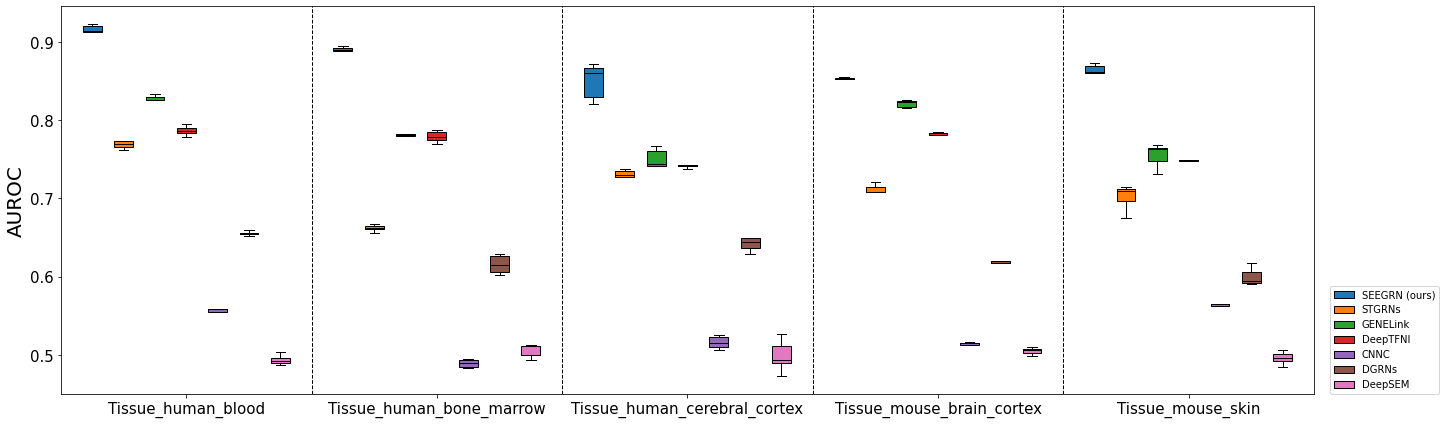

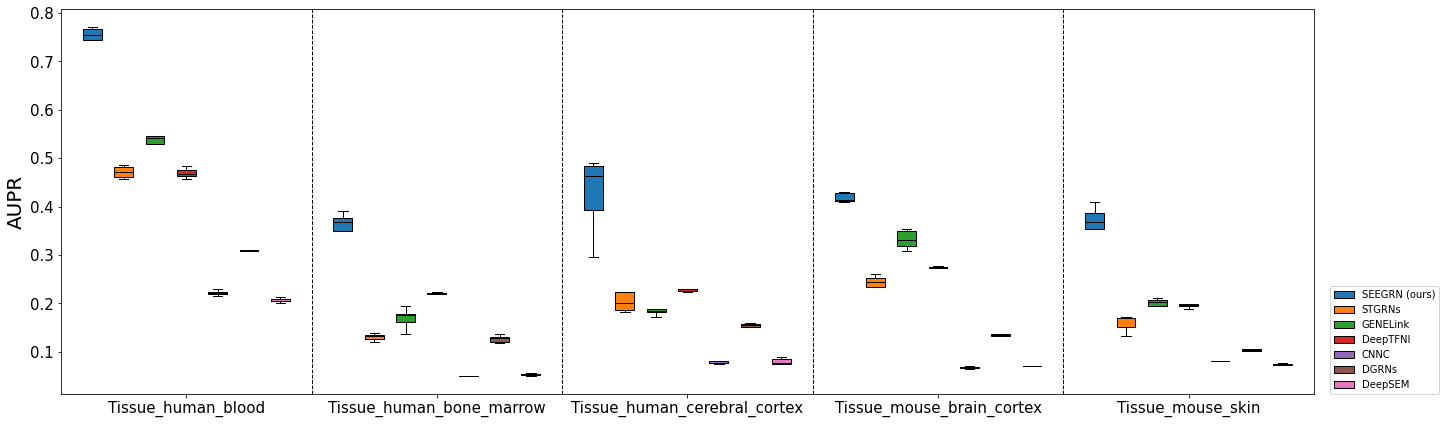

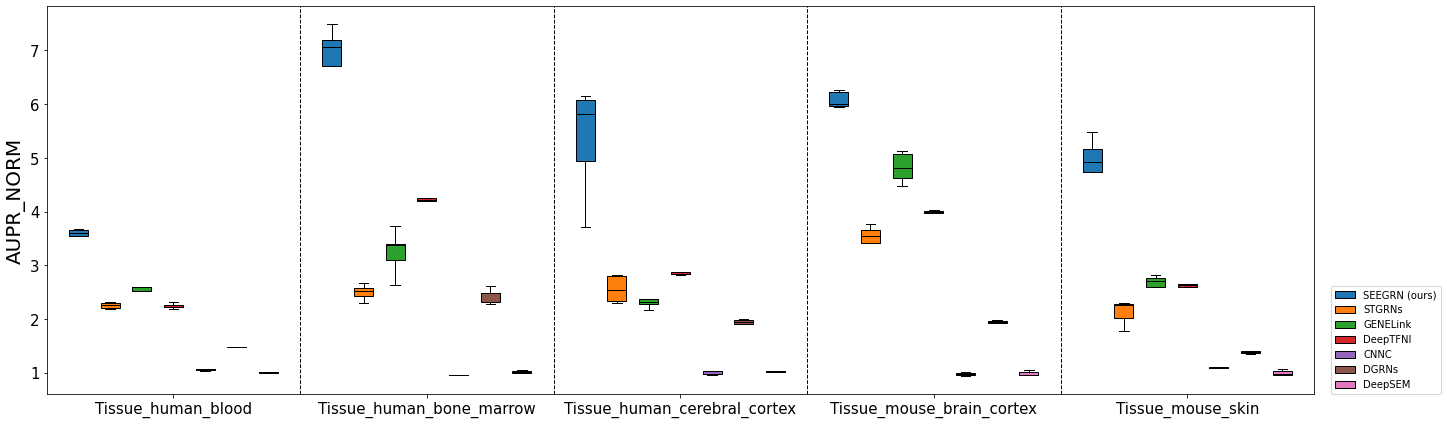

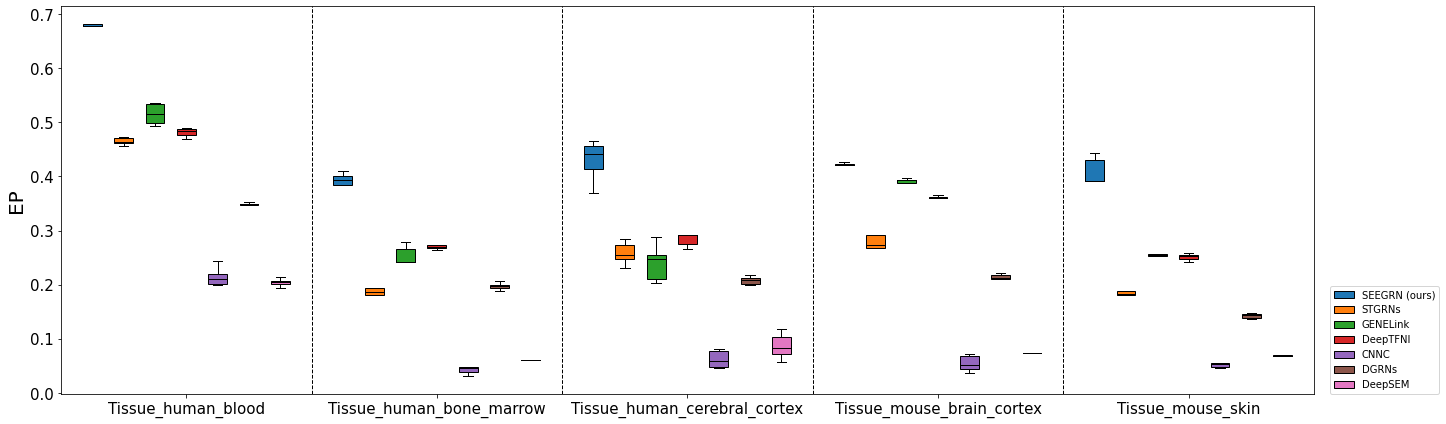

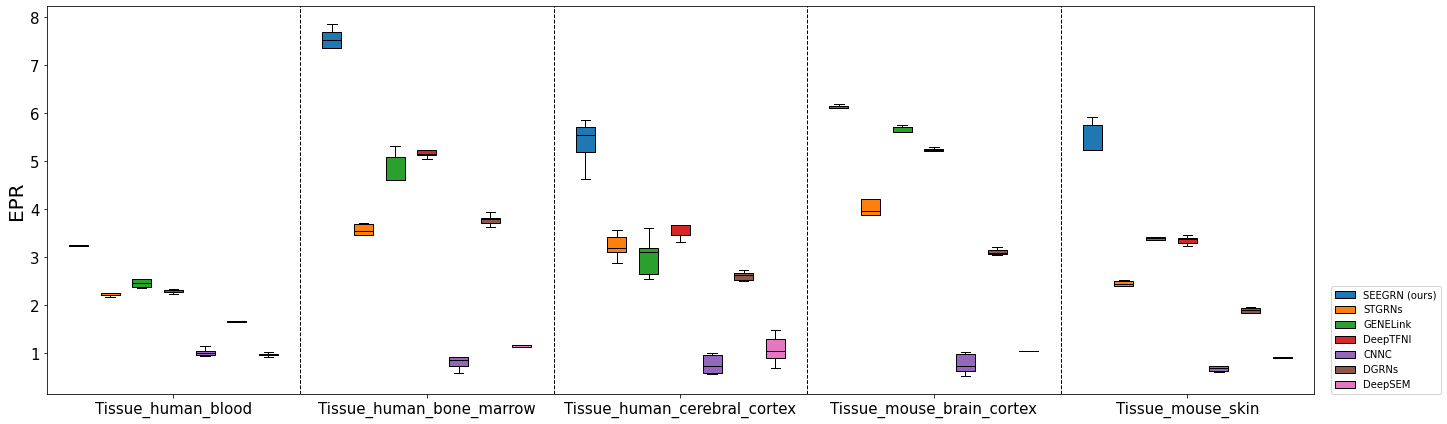

In [10]:
plot_model_comparison_tissue_specific_with_seed('auroc', df_tissue_specific=df_tissue_specific_auroc)
plot_model_comparison_tissue_specific_with_seed('aupr', df_tissue_specific=df_tissue_specific_aupr)
plot_model_comparison_tissue_specific_with_seed('aupr_norm', df_tissue_specific=df_tissue_specific_aupr_norm)
plot_model_comparison_tissue_specific_with_seed('ep', df_tissue_specific=df_tissue_specific_ep)
plot_model_comparison_tissue_specific_with_seed('epr', df_tissue_specific=df_tissue_specific_epr)